# **LAB 04**

## **Esercizio 4.1**

In questo esercizio è stato implementato il calcolo della distribuzione delle velocità delle particelle e il suo confronto con la distribuzione teorica di Maxwell-Boltzmann.

Per quanto riguarda la distribuzione teorica, in meccanica statistica la distribuzione di Maxwell-Boltzmann descrive la distribuzione delle velcoità delle particelle in un gas ideale tridimensionale. Utilizzando le unità ridotte di Lennard-Jones, questa assume la forma: 

$$p(v^*,T^*) = \frac{1}{(2\pi T^*)^{3/2}} 4\pi (v^*)^2 e^{-\frac{(v^*)^2}{2 T^*}}$$


Per ottenere la distribuzione delle velocità a partire dalla simulazione, è stato costriuto un istogramma normalizzato delle velocità. Durante la simulazione, viene calcolato il modulo della velcoità di ciascuna particella e viene aggiornato il conteggio nel bin corrispondente. Per migliorare la qualità statistica dei risultati, è stata utilizzata la tecnica del data blocking: dunque, per ogni bin dell'istogramma viene calcolata la media su ciascun blocco, la media progressiva e l'errore sulla media. 

Vengono dunque confrontate la distribuzione teorica di Maxwell-Boltzmann e la distribuzione ottenuta dalla simulazione (si usano in particolare i dati ottenuti dalla media progressiva a seguito dell'ultimo blocco). Per la curva teorica è stata utilizzata la temperatura simulata all'ultimo blocco, pari a $T = 1.41508$ K. Il confronto è stato effettuato tramite il grafico riportato di seguito. 

Si osserva che la distribuzione simulata segue bene l'andamento teorico ed eventuali discrepanze sono compatibili con le incertezze statistiche. 

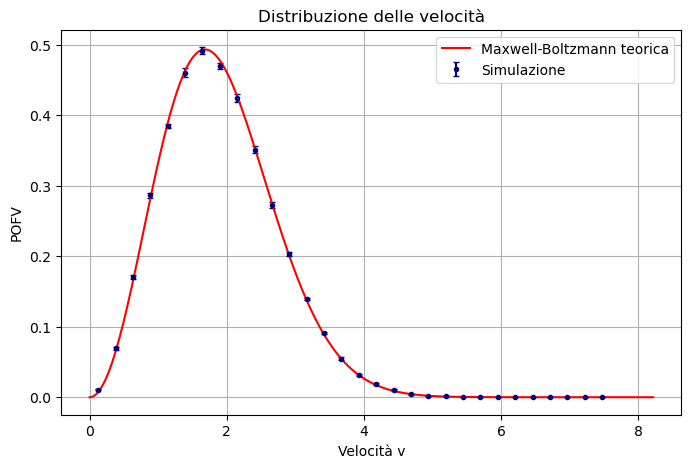

Integrale distribuzione simulata: 1.0000005983682172


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# PARAMETRI FISICI
m = 1.0        # massa particella (unità arbitrarie)
kB = 1.0       # costante di Boltzmann (unità arbitrarie)
T = 1.41508    # temperatura (unità arbitrarie)

# LETTURA DATI DA FILE
data = np.loadtxt("esercizio4.1/NSL_SIMULATOR/OUTPUT/pofv.dat")
v = data[:,0]
global_avg = data[:,2]
error = data[:,3]

# FUNZIONE MAXWELL-BOLTZMANN (teorica)
def maxwell_boltzmann(v,m,kB,T):
    factor = 4 * np.pi * (m /(2 * np.pi * kB * T)) ** (3/2)
    return factor * v**2 * np.exp(-m * v**2 / (2 * kB * T))

v_theory = np.linspace(0, max(v)*1.1, 500)
P_MB = maxwell_boltzmann(v_theory, m, kB, T); 

# PLOT
plt.figure(figsize=(8,5))
plt.errorbar(v, global_avg, yerr=error, fmt='o',markersize=3, label="Simulazione", capsize=2, color = 'navy')
plt.plot(v_theory, P_MB, label="Maxwell-Boltzmann teorica", color = 'red')
plt.xlabel("Velocità v")
plt.ylabel("POFV")
plt.title("Distribuzione delle velocità")
plt.legend()
plt.grid(True)
plt.show()


# INTEGRALE NUMERICO
integrale = np.sum(global_avg * np.diff(v, append=v[-1] + (v[1]-v[0])))
print("Integrale distribuzione simulata:", integrale)


Per verificare la correttezza dell'implementazione è stato calcolato l’integrale numerico della distribuzione simulata (cioè la somma sui bin moltiplicata per la larghezza del bin):

$$ \sum_i p(v_i) \Delta v \approx 1 $$

Il risultato ottenuto è compatibile con 1, a conferma che l’istogramma è correttamente normalizzato e rappresenta una distribuzione di probabilità.

## **Esercizio 4.2**

In questo esercizio viene stiudiata l'evoluzione di un sistema di particelle interagenti tramite potenziale di Lennard-Jones; viene quindi mostrato che una distribuzione iniziale fortemente non fisica delle velocità evolve spontaneamente verso la distribuzione di Maxwell-Boltzmann. 

La simulazione è stata eseguita in unità ridotte di Lennard-Jones, ponendo:
- densità $\rho^* = 0.05$ (fase gas)
- temperatura iniziale $T^* = 2.0$
- raggio di cut-off $r_c = 5.0$

Per simulare un sistema inizialmente a bassa entropia, sono state imposte le seguenti condizioni:
- *Posizioni*: le particelle sono state disposte su un reticolo cristallino fcc, occupando solo metà della scatola di simulazione in ciascuna direzione. Questo produce una configurazione altamente ordinata e non omogenea.
- *Velocità*: è stata imposta una distribuzione iniziale di tipo delta, assegnando a ciascuna particella una velocità $v_x = \pm v_0$ (con probabilità uguale) e $v_y = v_z = 0$, dove $v_0 = \sqrt{3 T}$. Questa scelta deriva dal fatto che, in unità ridotte, l’energia cinetica media per particella è $\frac{3}{2} T$ (con $k_B = 1$ e $m = 1$), mentre per una particella con velocità fissata vale $\frac{1}{2} v_0^2$. Impostando queste due quantità uguali si ottiene $\frac{1}{2} v_0^2 = \frac{3}{2} T$, da cui segue $v_0 = \sqrt{3 T}$. In questo modo tutte le particelle hanno lo stesso modulo della velocità, ma direzioni limitate, creando una distribuzione molto lontana da quella di equilibrio.

Il sistema è stato evoluto e durante la simulazione sono state misurate le distribuzioni di velocità $p(v)$ a diversi tempi (blocchi), al fine di osservare la loro evoluzione. Per verificare quantitativamente il risultato, la distribuzione simulata è stata confrontata con la distribuzione teorica di Maxwell-Boltzmann:

$$ p(v) = 4\pi \left( \frac{m}{2\pi k_B T} \right)^{3/2} v^2 e^{-\frac{m v^2}{2 k_B T}} $$

La temperatura durante la simulazione non è costante, ma fluttua; è quindi stata definita una temperatura efficace $T_{\mathrm{eff}}$, ottenuta mediando la temperatura fino al blocco considerato.

Nella figura riportata di seguito sono mostrati i grafici ottenuti durante la simulazione e il confronto con la distribuzione teorica. 

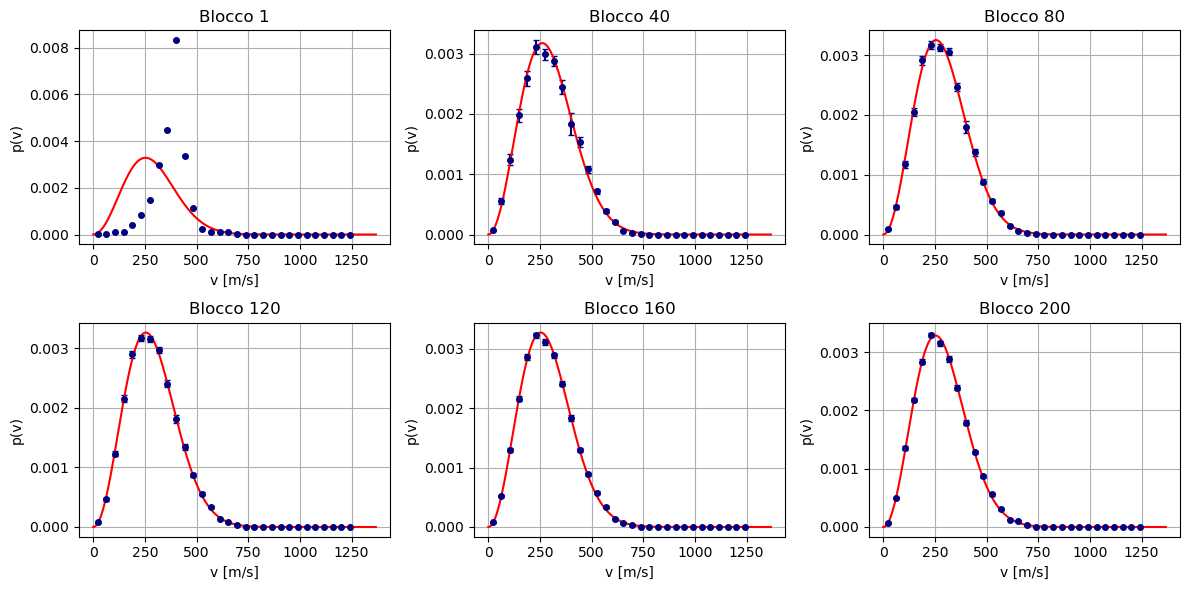

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import math

# PARAMETRI FISICI
kB = 1.380649e-23   
amu = 1.66054e-27 
epsilon_kB = 120.0         
epsilon = kB * epsilon_kB  
m = 39.948 * amu  

# CONVERSIONE VELOCITA'
v_scale = np.sqrt(epsilon / m) # fattore di conversione velocità


# TEMPERATURE
temp_data = np.loadtxt("esercizio4.2/NSL_SIMULATOR/OUTPUT/temperature.dat")
T = temp_data[:,2]
T_real = T * epsilon_kB

def maxwell_boltzmann(v,m,kB,T):
    factor = 4 * np.pi * (m /(2 * np.pi * kB * T)) ** (3/2)
    return factor * v**2 * np.exp(-m * v**2 / (2 * kB * T))


# PARAMETRI SIMULAZIONE
n_block=200; 
n_grafici=5;
passo = int(n_block/n_grafici)

# LISTA FILE
files = sorted(glob.glob("esercizio4.2/NSL_SIMULATOR/OUTPUT/pofv_*.dat"))
n_files = len(files)
n_cols = 3
n_rows = math.ceil(n_files / n_cols)


# CREAZIONE FIGURA
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for i, filename in enumerate(files):

    data = np.loadtxt(filename)
    v = data[:,0]
    global_avg = data[:,2]
    error = data[:,3]

    v_real = v * v_scale
    global_real = global_avg / v_scale
    error_real = error / v_scale

    if i == 0: 
        temp_index = 0
    else: 
        temp_index = i*passo

    v_theory = np.linspace(0, max(v_real)*1.1, 500)
    P_MB = maxwell_boltzmann(v_theory, m, kB, T_real[temp_index-1])

    ax = axes[i]
    ax.errorbar(v_real, global_real, yerr=error_real, fmt='o', markersize=4, capsize=2, color='navy')
    ax.plot(v_theory, P_MB, 'r-')

    if i == 0:
        ax.set_title("Blocco 1")
    else:
        ax.set_title(f"Blocco {passo*i}")
   
    ax.set_xlabel("v [m/s]")
    ax.set_ylabel("p(v)")
    ax.grid(True)

# RIMOZIONE eventuali subplot vuoti
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()



I risultati mostrano chiaramente che inizialmente la distribuzione è concentrata attorno a un valore (simile a una delta) e che nel tempo si allarga progressivamente a causa delle collisioni tra particelle convergendo infine alla distribuzione di Maxwell-Boltzmann.

Sebbene la simulazione sia eseguita in unità ridotte (con $\sigma = 1$, $\epsilon = 1$, $m = 1$), è stato possibile convertire i risultati in unità fisiche utilizzando i parametri dell’Argon: $\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m = 39.948$ amu. 
Le velocità sono state convertite tramite:
$$ v = v^* \sqrt{\frac{\epsilon}{m}} $$
mentre la distribuzione è stata scalata come:
$$ p(v) = \frac{p(v^*)}{\sqrt{\epsilon/m}} $$
Questo permette di ottenere distribuzioni in unità SI, con velocità dell’ordine di qualche centinaio di m/s, in accordo con i valori fisici attesi per un gas reale.

## **Esercizio 4.3**

#### INTRODUZIONE
In questo esercizio si vuole studiare la reversibilità delle simulazioni di Molecular Dynamics. Le equazioni del moto di Newton sono infatti invarianti per inversione temporale: in linea di principio, invertendo tutte le velocità delle particelle, il sistema dovrebbe ripercorrere esattamente la traiettoria seguita in precedenza e ritornare alla configurazione iniziale. Lo scopo dell'esercizio è verificare se questa reversibilità teorica possa essere osservata anche in una simulazione numerica. 

A partire dagli stati finali ottenuti nell'esercizio 4.2, vengono considerate due simulazioni:

- una simulazione breve (short run) di $5 \times 10^3$ time-step, suddivisi in 50 blocchi da 100 step ciascuno;
- una simulazione lunga (long run) di $5 \times 10^4$ time-step, suddivisi in 100 blocchi da 500 step ciascuno; 

Per entrambe le simulazioni viene invertita l'evoluzione temporale e si osserva se il sistema riesce a tornare verso la configurazione iniziale, caratterizzata da una bassa entropia. Per monitorare il comportamento del sistema vengono confrontate l'energia potenziale e la temperatura mediate a blocchi nel caso normale e nel caso con inversione temporale.


#### IMPLEMENTAZIONE
Innanzitutto, sono state eseguite le due simulazioni dirette. Al termine di ciascuna simulazione sono state salvate sia la configurazione finale (`config.xyz`) sia la configurazione del passo precedente (`config-1.xyz`). Questi file sono stati successivamente copiati nella cartella `INPUT` del simulatore modificato per l'evoluzione inversa.

Per evitare una nuova inizializzazione casuale delle velocità, nel file input.dat è stato impostato `RESTART 1`: in questo modo il programma legge automaticamente la configurazione precedente invece di generare nuove velocità.

La modifica principale è stata introdotta nella funzione `InitializeVelocities()`. Nel simulatore originale la configurazione corrente e quella precedente vengono utilizzate per ricostruire le velocità iniziali. Per invertire il verso del tempo è stato sufficiente scambiare i ruoli delle due configurazioni salvate:
- `config-1.xyz` viene letta come configurazione corrente (`xnew`);
- `config.xyz` viene letta come configurazione precedente (`xold`).

Poiché nel metodo di Verlet la velocità è proporzionale alla differenza tra queste due configurazioni, questo scambio equivale a cambiare il segno di tutte le velocità:

$$ v \rightarrow - v $$

La simulazione viene quindi fatta ripartire utilizzando queste condizioni iniziali, realizzando di fatto un'evoluzione temporale inversa.

#### ANALISI DEI RISULTATI
Per analizzare il comportamento del sistema sia durante l’evoluzione diretta (forward) sia durante l’evoluzione inversa (backward), sono state confrontate le principali osservabili termodinamiche, in particolare temperatura ed energia potenziale. Poiché la simulazione inversa rappresenta una traiettoria percorsa nel verso opposto del tempo, i dati relativi al backward sono stati ulteriormente invertiti rispetto all’asse temporale (numero di blocco). Questa operazione permette di rendere confrontabili le due evoluzioni punto per punto, come se entrambe fossero espresse nella stessa direzione temporale.

Nel caso della simulazione più breve (short run), le curve relative alla temperatura e all’energia potenziale mostrano un’elevata sovrapposizione tra evoluzione forward e backward, indicando che la dinamica è in grado di ripercorrere quasi esattamente lo stato iniziale quando le velocità vengono invertite. Questo comportamento è coerente con il fatto che, su tempi brevi, gli errori numerici introdotti dall’integrazione di Verlet rimangono piccoli e non sufficienti a compromettere la reversibilità della traiettoria. In questo regime, quindi, il sistema appare sostanzialmente reversibile dal punto di vista numerico.


Nel caso della simulazione più lunga (long run), il confronto tra evoluzione forward e backward (opportunamente invertita nel tempo) non mostra una vera sovrapposizione delle due traiettorie. A differenza del caso short run, la simulazione inversa non riesce a ricostruire correttamente la condizione iniziale della dinamica diretta e quindi si osserva una marcata discrepanza tra le due evoluzioni. Per evidenziare quantitativamente questo comportamento è stata analizzata la differenza tra le osservabili nelle due simulazioni. Sia per la temperatura sia per l’energia potenziale, tale differenza risulta significativa nei primi blocchi, indicando che la traiettoria invertita non è in grado di riportare il sistema nello stato microscopico iniziale. Questo comportamento evidenzia che, su tempi più lunghi, l’accumulo degli errori numerici e la forte sensibilità del sistema alle condizioni iniziali impediscono una ricostruzione fedele della dinamica inversa, portando alla perdita della reversibilità. 

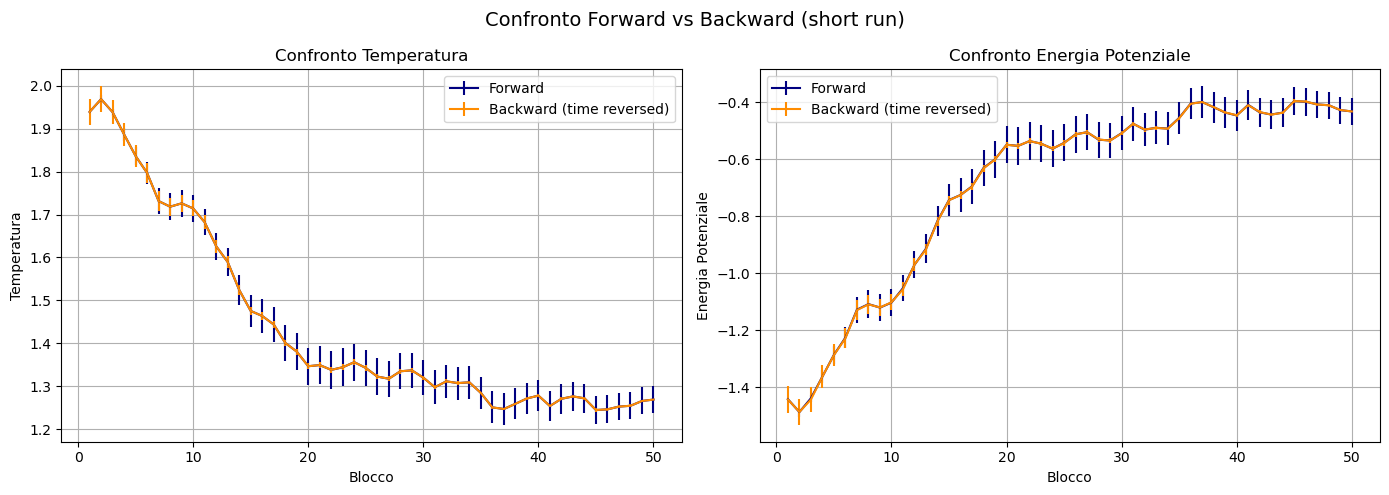

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# CARICAMENTO DATI
# Forward
temp_f = np.loadtxt("esercizio4.3/Normale/NSL_Simulator/OUTPUT_short/temperature.dat")
pot_f  = np.loadtxt("esercizio4.3/Normale/NSL_Simulator/OUTPUT_short/potential_energy.dat")

block_f = temp_f[:, 0]
T_f      = temp_f[:, 1]
err_T_f  = temp_f[:, 3]

U_f      = pot_f[:, 1]
err_U_f  = pot_f[:, 3]

# Backward
temp_b = np.loadtxt("esercizio4.3/Invertito/NSL_Simulator/OUTPUT_short/temperature.dat")
pot_b  = np.loadtxt("esercizio4.3/Invertito/NSL_Simulator/OUTPUT_short/potential_energy.dat")

block_b = temp_b[:, 0]
T_b      = temp_b[:, 1]
err_T_b  = temp_b[:, 3]

U_b      = pot_b[:, 1]
err_U_b  = pot_b[:, 3]



# INVERSIONE ASSE TEMPORALE BACKWARD
N_blocks = block_f[-1]
block_b_rev = N_blocks - block_b +1


fig, axs = plt.subplots(1, 2, figsize=(14,5))
# GRAFICO TEMPERATURA
axs[0].errorbar(block_f, T_f, yerr=err_T_f, markersize=2,
                label='Forward', color='navy')

axs[0].errorbar(block_b_rev, T_b, yerr=err_T_b, markersize=2,
                label='Backward (time reversed)', color='darkorange')

axs[0].set_xlabel("Blocco")
axs[0].set_ylabel("Temperatura")
axs[0].set_title("Confronto Temperatura")
axs[0].legend()
axs[0].grid(True)



# GRAFICO ENERGIA POTENZIALE
axs[1].errorbar(block_f, U_f, yerr=err_U_f, markersize=2,
                label='Forward', color='navy')

axs[1].errorbar(block_b_rev, U_b, yerr=err_U_b, markersize=2,
                label='Backward (time reversed)', color='darkorange')

axs[1].set_xlabel("Blocco")
axs[1].set_ylabel("Energia Potenziale")
axs[1].set_title("Confronto Energia Potenziale")
axs[1].legend()
axs[1].grid(True)


plt.suptitle("Confronto Forward vs Backward (short run)", fontsize=14)
plt.tight_layout()
plt.show()




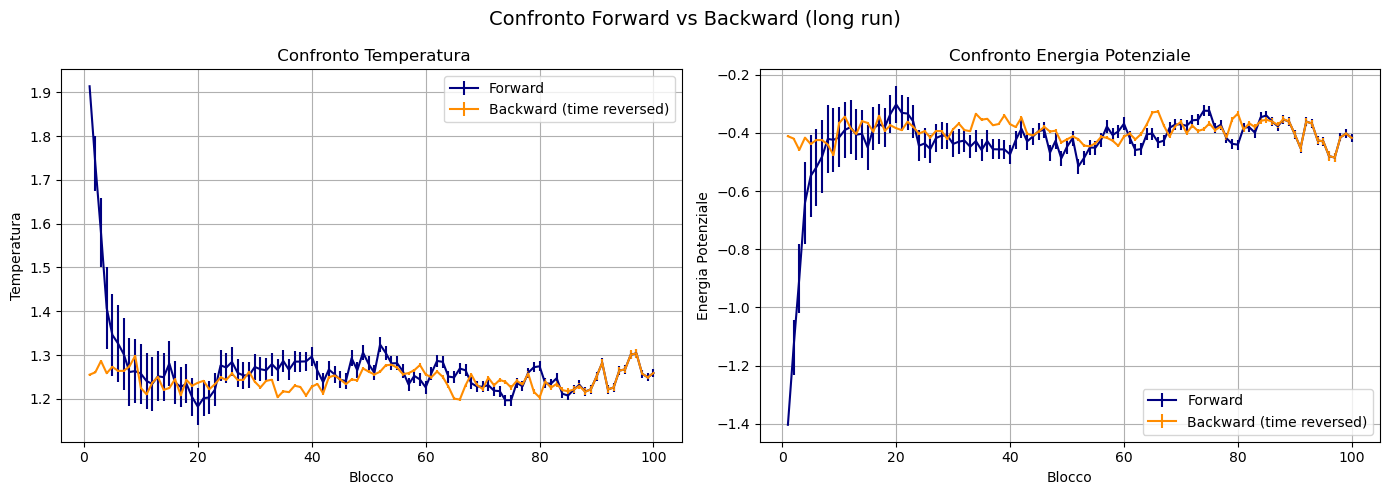

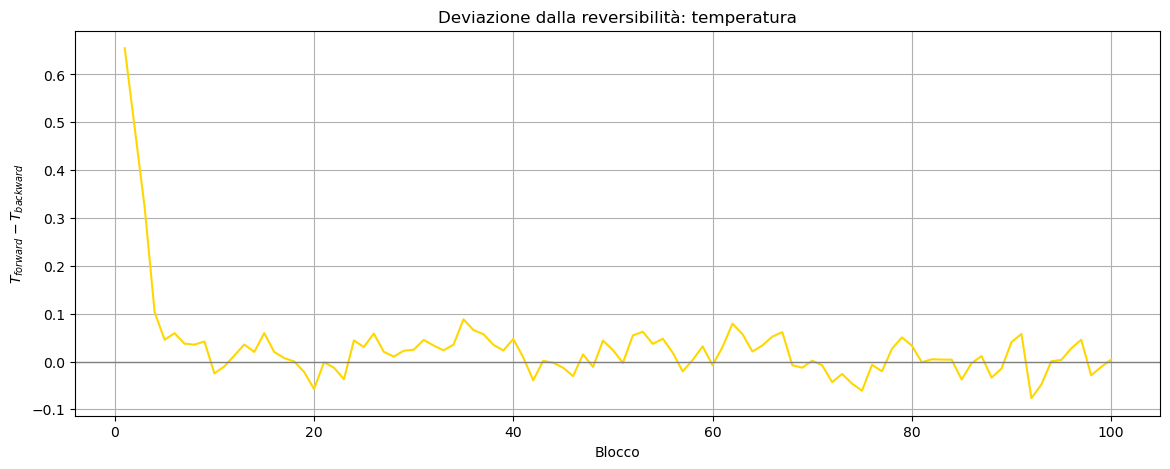

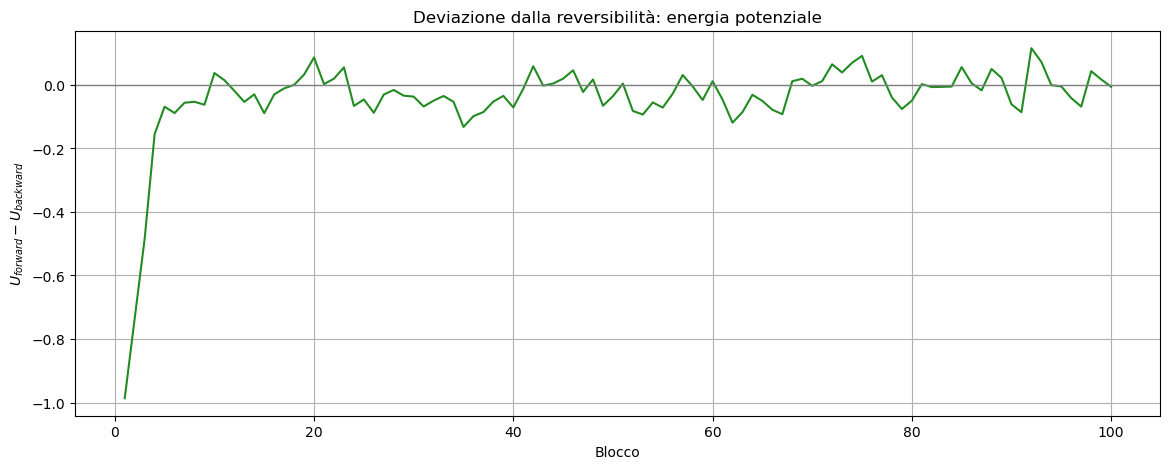

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# CARICAMENTO DATI
# Forward
temp_f = np.loadtxt("esercizio4.3/Normale/NSL_Simulator/OUTPUT_long/temperature.dat")
pot_f  = np.loadtxt("esercizio4.3/Normale/NSL_Simulator/OUTPUT_long/potential_energy.dat")

block_f = temp_f[:, 0]
T_f      = temp_f[:, 1]
err_T_f  = temp_f[:, 3]

U_f      = pot_f[:, 1]
err_U_f  = pot_f[:, 3]

# Backward
temp_b = np.loadtxt("esercizio4.3/Invertito/NSL_Simulator/OUTPUT_long/temperature.dat")
pot_b  = np.loadtxt("esercizio4.3/Invertito/NSL_Simulator/OUTPUT_long/potential_energy.dat")

block_b = temp_b[:, 0]
T_b      = temp_b[:, 1]
err_T_b  = temp_b[:, 3]

U_b      = pot_b[:, 1]
err_U_b  = pot_b[:, 3]


# INVERSIONE ASSE TEMPORALE BACKWARD
N_blocks = block_f[-1]
block_b_rev = N_blocks - block_b +1


fig, axs = plt.subplots(1, 2, figsize=(14,5))

# GRAFICO TEMPERATURA
axs[0].errorbar(block_f, T_f, yerr=err_T_f, markersize=2,
                label='Forward', color='navy')

axs[0].errorbar(block_b_rev, T_b, yerr=err_T_b, markersize=2,
                label='Backward (time reversed)', color='darkorange')

axs[0].set_xlabel("Blocco")
axs[0].set_ylabel("Temperatura")
axs[0].set_title(" Confronto Temperatura")
axs[0].legend()
axs[0].grid(True)


# GRAFICO ENERGIA POTENZIALE
axs[1].errorbar(block_f, U_f, yerr=err_U_f, markersize=2,
                label='Forward', color='navy')

axs[1].errorbar(block_b_rev, U_b, yerr=err_U_b, markersize=2,
                label='Backward (time reversed)', color='darkorange')

axs[1].set_xlabel("Blocco")
axs[1].set_ylabel("Energia Potenziale")
axs[1].set_title("Confronto Energia Potenziale")
axs[1].legend()
axs[1].grid(True)


plt.suptitle("Confronto Forward vs Backward (long run)", fontsize=14)
plt.tight_layout()
plt.show()


# GRAFICO DIFFERENZE: TEMPERATURA
T_diff = T_f - T_b

plt.figure(figsize=(14,5))

plt.plot(block_f, T_diff, color='gold')

plt.axhline(0, color='grey', linewidth=1)

plt.xlabel("Blocco")
plt.ylabel(r"$T_{forward} - T_{backward}$")
plt.title("Deviazione dalla reversibilità: temperatura")
plt.grid()

plt.show()

# GRAFICO DIFFERENZE: ENERGIA POTENZIALE
U_diff = U_f - U_b

plt.figure(figsize=(14,5))

plt.plot(block_f, U_diff, color='forestgreen')

plt.axhline(0, color='grey', linewidth=1)

plt.xlabel("Blocco")
plt.ylabel(r"$U_{forward} - U_{backward}$")
plt.title("Deviazione dalla reversibilità: energia potenziale")
plt.grid()

plt.show()